In [1]:
import os

dataset_path = "datasets/archive/PlantVillage"

print("Dataset Path:", dataset_path)
print("Folders Found:")

for folder in os.listdir(dataset_path):
    print(folder)

Dataset Path: datasets/archive/PlantVillage
Folders Found:
Potato___Late_blight
Tomato_Late_blight
Tomato_healthy
Tomato_Leaf_Mold
Pepper__bell___Bacterial_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato_Bacterial_spot
Potato___healthy
Tomato__Tomato_mosaic_virus
Pepper__bell___healthy
Potato___Early_blight
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Septoria_leaf_spot
Tomato_Early_blight


In [8]:
import os
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import tensorflow as tf

In [9]:
import os

dataset_path = "datasets/archive/PlantVillage"

classes = os.listdir(dataset_path)

print("Total Disease Categories:", len(classes))

Total Disease Categories: 15


In [10]:
import os

dataset_path = "datasets/archive/PlantVillage"

total_images = 0

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    total_images += len(os.listdir(folder_path))

print("Total Images:", total_images)

Total Images: 20639


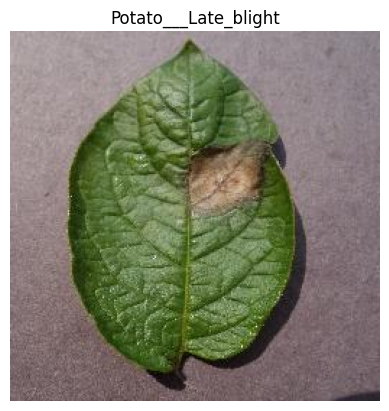

In [11]:
import matplotlib.pyplot as plt
import os

dataset_path = "datasets/archive/PlantVillage"

folder = os.listdir(dataset_path)[0]
folder_path = os.path.join(dataset_path, folder)

image_name = os.listdir(folder_path)[0]
image_path = os.path.join(folder_path, image_name)

img = plt.imread(image_path)

plt.imshow(img)
plt.title(folder)
plt.axis("off")
plt.show()

In [12]:
pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "datasets/archive/PlantVillage",
    image_size=(128, 128),
    batch_size=32
)

print("Dataset Loaded Successfully")

Found 20638 files belonging to 15 classes.
Dataset Loaded Successfully


In [3]:
print(dataset.class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "datasets/archive/PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "datasets/archive/PlantVillage",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

print("Dataset Split Successfully")

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Dataset Split Successfully


In [5]:
len(dataset.class_names)

15

In [6]:
import os
import pandas as pd

dataset_path = "datasets/archive/PlantVillage"

class_counts = {}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    class_counts[folder] = len(os.listdir(folder_path))

df = pd.DataFrame(
    class_counts.items(),
    columns=["Disease", "Image_Count"]
)

df = df.sort_values(by="Image_Count", ascending=False)

df

,Disease,Image_Count
12,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
7,Tomato_Bacterial_spot,2127
1,Tomato_Late_blight,1909
13,Tomato_Septoria_leaf_spot,1771
5,Tomato_Spider_mites_Two_spotted_spider_mite,1676
2,Tomato_healthy,1591
10,Pepper__bell___healthy,1478
6,Tomato__Target_Spot,1404
11,Potato___Early_blight,1000
0,Potato___Late_blight,1000


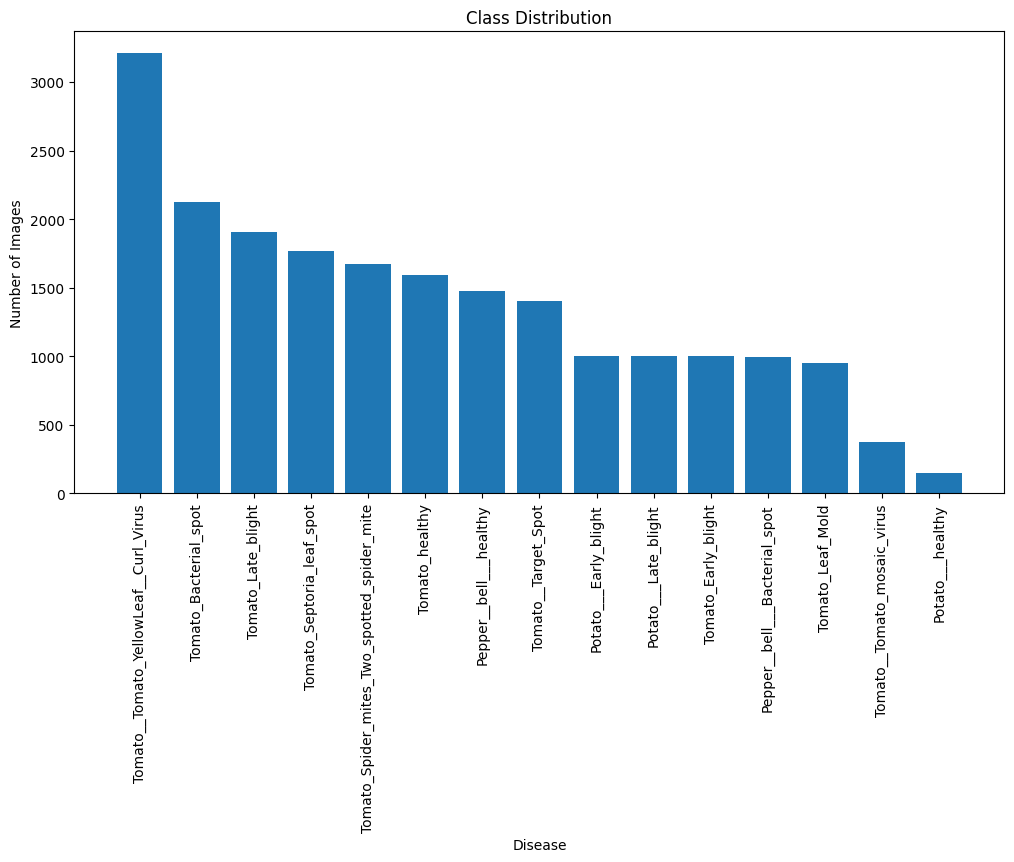

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["Disease"], df["Image_Count"])
plt.xticks(rotation=90)
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

In [8]:
import os
from PIL import Image

dataset_path = "datasets/archive/PlantVillage"

folder = os.listdir(dataset_path)[0]
folder_path = os.path.join(dataset_path, folder)

image_name = os.listdir(folder_path)[0]
image_path = os.path.join(folder_path, image_name)

img = Image.open(image_path)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (256, 256)
Image Mode: RGB


In [9]:
image_size=(128,128)

In [10]:
import os
from PIL import Image

dataset_path = "datasets/archive/PlantVillage"

corrupted = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    for image in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image)

        try:
            img = Image.open(image_path)
            img.verify()
        except:
            corrupted.append(image_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 1


In [11]:
print(corrupted)

['datasets/archive/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c']


In [12]:
import os

os.remove("datasets/archive/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c")

print("Corrupted file removed successfully")

Corrupted file removed successfully


In [13]:
import os
from PIL import Image

dataset_path = "datasets/archive/PlantVillage"

corrupted = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    for image in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image)

        try:
            img = Image.open(image_path)
            img.verify()
        except:
            corrupted.append(image_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [14]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

print("Normalization Layer Created")

Normalization Layer Created


In [15]:
for images, labels in train_ds.take(1):
    first_image = images[0]

    print("Before Normalization")
    print("Min Pixel Value:", first_image.numpy().min())
    print("Max Pixel Value:", first_image.numpy().max())

    normalized_image = normalization_layer(first_image)

    print("\nAfter Normalization")
    print("Min Pixel Value:", normalized_image.numpy().min())
    print("Max Pixel Value:", normalized_image.numpy().max())

Before Normalization
Min Pixel Value: 0.0
Max Pixel Value: 231.0

After Normalization
Min Pixel Value: 0.0
Max Pixel Value: 0.9058824


In [16]:
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization Applied Successfully")

Normalization Applied Successfully


In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

print("Data Augmentation Layer Created")

Data Augmentation Layer Created


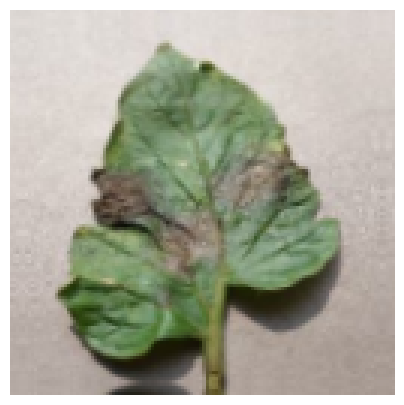

In [18]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    augmented_image = data_augmentation(images)

    plt.figure(figsize=(5,5))
    plt.imshow(augmented_image[0].numpy())
    plt.axis("off")
    plt.show()

In [19]:
class_names = dataset.class_names

print("Number of Classes:", len(class_names))
print(class_names)

Number of Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    
    data_augmentation,

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(15, activation='softmax')
])

print("CNN Model Created Successfully")

CNN Model Created Successfully


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 126, 126, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 63, 63, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 61, 61, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 28, 28, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 14, 14, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 25088)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 15)               │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

print("Early Stopping Created")

Early Stopping Created


In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Model Checkpoint Created")

Model Checkpoint Created


In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3665 - loss: 1.9592
Epoch 1: val_accuracy improved from None to 0.68379, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 91s 175ms/step - accuracy: 0.5067 - loss: 1.5322 - val_accuracy: 0.6838 - val_loss: 0.9308
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6845 - loss: 0.9321
Epoch 2: val_accuracy improved from 0.68379 to 0.73540, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 95s 184ms/step - accuracy: 0.7051 - loss: 0.8722 - val_accuracy: 0.7354 - val_loss: 0.7698
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7454 - loss: 0.7402
Epoch 3: val_accuracy improved from 0.73540 to 0.78580, saving model to models/best_model.keras

Epoch 3: finished saving model to models/best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 95s 1

In [26]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8755 - loss: 0.4065
Validation Accuracy: 0.875454306602478
Validation Loss: 0.406491756439209


In [29]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [30]:
print("True Labels:", len(y_true))
print("Predicted Labels:", len(y_pred))

True Labels: 4127
Predicted Labels: 4127


In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.82      0.94      0.88       176
                     Pepper__bell___healthy       0.92      0.99      0.95       280
                      Potato___Early_blight       0.95      0.94      0.95       194
                       Potato___Late_blight       0.95      0.71      0.81       224
                           Potato___healthy       0.67      0.34      0.45        29
                      Tomato_Bacterial_spot       0.98      0.87      0.92       414
                        Tomato_Early_blight       0.71      0.89      0.79       200
                         Tomato_Late_blight       0.85      0.92      0.88       369
                           Tomato_Leaf_Mold       0.93      0.73      0.82       208
                  Tomato_Septoria_leaf_spot       0.66      0.93      0.77       337
Tomato_Spider_mites_Two_spotted_spider_mite       0.95      0.68

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(15, 15)


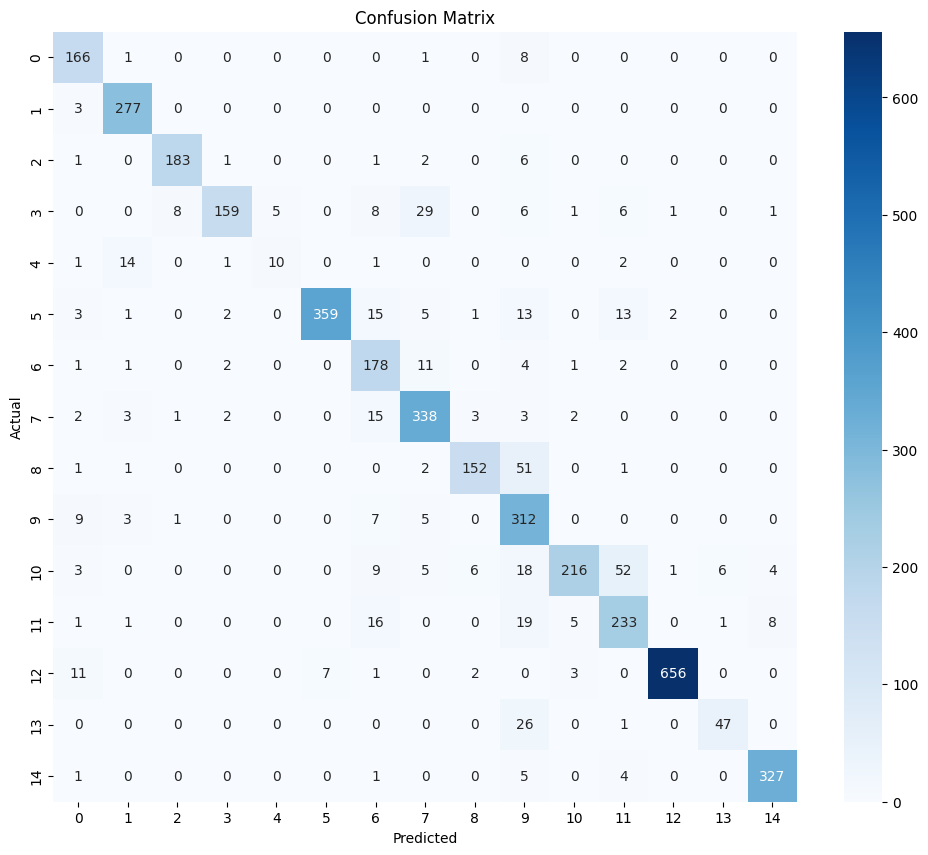

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:

print("Baseline CNN Accuracy:", accuracy)

Baseline CNN Accuracy: 0.875454306602478


In [36]:
model.save("models/final_crop_disease_model.keras")

print("Final Model Saved")

Final Model Saved


In [37]:
from tensorflow.keras.models import load_model

final_model = load_model(
    "models/final_crop_disease_model.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [39]:
class_names = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

print("Classes Loaded Successfully")

Classes Loaded Successfully


In [40]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img = img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

print("Image Preprocessing Function Created")

Image Preprocessing Function Created


In [45]:
def predict_disease(image_path):
    
    img = preprocess_image(image_path)

    prediction = final_model.predict(img, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    print("Disease:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")
   

In [46]:
print("Prediction Function Created")

Prediction Function Created


In [48]:
import os

folder = "datasets/archive/PlantVillage/Tomato_Early_blight"

print(os.listdir(folder)[:5])

['9cb2abac-0c5b-4b49-ad84-d97805de271c___RS_Erly.B 7457.JPG', '39da27eb-fde9-474b-bf0a-1374901ed82b___RS_Erly.B 7394.JPG', '3253ff4e-90ab-475a-89d2-f99875c53367___RS_Erly.B 8356.JPG', 'f62e84ae-2bd4-4b15-918a-639c0470c25d___RS_Erly.B 7761.JPG', 'b24f8f98-4bfe-4605-85f5-738fc09e58fe___RS_Erly.B 6406.JPG']


In [50]:
test_image = "datasets/archive/PlantVillage/Tomato_Early_blight/9cb2abac-0c5b-4b49-ad84-d97805de271c___RS_Erly.B 7457.JPG"

predict_disease(test_image)

Disease: Tomato_Early_blight
Confidence: 52.97 %


In [51]:
treatments = {
    "Tomato_Early_blight": "Apply Mancozeb fungicide and remove infected leaves.",
    "Tomato_Late_blight": "Use copper-based fungicides and avoid overhead watering.",
    "Tomato_healthy": "No disease detected. Maintain regular care."
}

print("Treatment Dictionary Created")

Treatment Dictionary Created


In [52]:
def predict_disease_with_treatment(image_path):

    img = preprocess_image(image_path)

    prediction = final_model.predict(img, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    treatment = treatments.get(
        predicted_class,
        "Treatment information not available."
    )

    print("Disease:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")
    print("Treatment:", treatment)

In [53]:
print("Enhanced Prediction Function Created")

Enhanced Prediction Function Created


In [54]:
predict_disease_with_treatment(test_image)

Disease: Tomato_Early_blight
Confidence: 52.97 %
Treatment: Apply Mancozeb fungicide and remove infected leaves.


In [2]:
import sys
print(sys.executable)

/home/tanushri/anaconda3/bin/python


In [6]:
import tensorflow as tf

print("TensorFlow Loaded")

I0000 00:00:1780321396.669228    4322 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780321396.670515    4322 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780321397.004075    4322 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780321398.625720    4322 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow Loaded


In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "datasets/archive/PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=32
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


E0000 00:00:1780321425.330018    4322 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
print(train_ds.class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
